# CMI - LSTM Classifier Starter

This is meant as a training notebook to get started. We train a simple LSTM classifier on the IMU signals. A corresponding inference notebook is done afterwards.

**All comments welcome!**



Before we start let us discuss and elaborate on the individual parts.

1. Load training data (IMU).
    - For simplicity we skip demographics data and other, sometime missing features.

2. Split data into training and validation set. This must be done on the ``sequence_id`` level in order to avoid mixing different sequences.

3. Implement a scikit-learn like preprocessing that can also be stored.

4. Create a dataset that prepares the sequences. 
    - Sequences have a maximum length.
    - Since gesture is at the end, take the maximum lenght from the right side.

5. Define a data collator that pads sequences to equal length, optionally pads target and outputs an additional mask.

6. There are different options to classify:
    - Output logits are only processed for the last hidden state. In this way one has only 1 output, but I'm not sure how to code this correctly.
    - Each hidden state passes thru the same classifier to create an logits for each instance. This is more straightforward, however we can have issues in the beginning when gesture did not even start and about the overall weight of the sequence.
    - Output logits are only considered when gesture has started. This might be doable by using an appropriate ``gesture_mask``, but again might suffer from weighting effects.
    - There is also the possibility to consider aggregates from all hidden states, something like an average before the classifier.
    - I think ultimately the code for each one is very similar, when the main feature is using the loss masking feature, i.e., setting ``target=-100`` so that it is not included in the loss computation.

7. Define model using average over all hidden states as a start.

8. Create training loop with validation and checkpointing.

9. Compute competition metric on validation set.

## Change Log
- V2: Add model components like dropout or bidirectionality. Include scheduler and different checkpointing mechanism.
- V4: Fix model eval mode, add label smoothing.

# Import & Settings

In [146]:
import os
import pathlib
import time
import collections
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from metric import score as cmi_score

In [2]:
SEED = 2025
BASE_DIR = pathlib.Path(".")
OUT_DIR = pathlib.Path(".")
print("output dir:", OUT_DIR)

# data
ID_COL = "sequence_id"
SEQ_COL = "sequence_counter"

TARGET = "gesture"
MAX_LENGTH = 60

# model
NUM_CLASSES = 18
HIDDEN_SIZE = 256
N_LAYERS = 3
N_CLF_LAYERS = 2
BIDIRECTIONAL = True
DROP = 0.15
LABEL_SMOOTHING = 0.1

# trainig
BATCH_SIZE = 16
EPOCHS = 70
LR = 1e-3
LR_MIN = 1e-5
DEVICE = torch.device("cuda")

output dir: .


In [3]:
FEATURES = ['acc_x',
 'acc_y',
 'acc_z',
 'rot_w',
 'rot_x',
 'rot_y',
 'rot_z',
 'thm_1',
 'thm_2',
 'thm_3',
 'thm_4',
 'thm_5']

# Load

In [4]:
path_data = BASE_DIR / "train.csv"
header = pd.read_csv(path_data, nrows=0)
columns = header.columns
columns = [x for x in columns if not x.startswith("tof")]

columns

['row_id',
 'sequence_type',
 'sequence_id',
 'sequence_counter',
 'subject',
 'orientation',
 'behavior',
 'phase',
 'gesture',
 'acc_x',
 'acc_y',
 'acc_z',
 'rot_w',
 'rot_x',
 'rot_y',
 'rot_z',
 'thm_1',
 'thm_2',
 'thm_3',
 'thm_4',
 'thm_5']

In [5]:
data = pd.read_csv(path_data, usecols=columns)
data.shape

(574945, 21)

In [6]:
cat = pd.Categorical(data[TARGET], ordered=True).dtype
data[TARGET] = pd.Categorical(data[TARGET], ordered=True)
data[TARGET] = data[TARGET].cat.codes

In [7]:
cat.categories, cat.ordered

(Index(['Above ear - pull hair', 'Cheek - pinch skin', 'Drink from bottle/cup',
        'Eyebrow - pull hair', 'Eyelash - pull hair',
        'Feel around in tray and pull out an object',
        'Forehead - pull hairline', 'Forehead - scratch', 'Glasses on/off',
        'Neck - pinch skin', 'Neck - scratch', 'Pinch knee/leg skin',
        'Pull air toward your face', 'Scratch knee/leg skin', 'Text on phone',
        'Wave hello', 'Write name in air', 'Write name on leg'],
       dtype='object'),
 True)

In [8]:
assert NUM_CLASSES == len(cat.categories)
print(f"#{NUM_CLASSES} classes found.")

#18 classes found.


# Split

In [9]:
def add_split(data):
    data["split"] = -1
    df = data[[ID_COL, TARGET]].value_counts().reset_index()[[ID_COL, TARGET]].reset_index(drop=True)
    splitter = StratifiedKFold(shuffle=True, random_state=SEED)
    for i, (__, i_valid) in enumerate(splitter.split(df, y=df[TARGET])):
        ind = df.iloc[i_valid].index
        ids = df.loc[ind][ID_COL].values
        ind = data[data[ID_COL].isin(ids)].index
        data.loc[ind, "split"] = i

In [10]:
add_split(data)

In [11]:
splits = {}
for x in sorted(data["split"].unique()):
    splits[f"split_{x}"] = data[data["split"] == x].groupby(ID_COL)[TARGET].first().value_counts()
pd.DataFrame(splits)

,split_0,split_1,split_2,split_3,split_4
gesture,,,,,
0,128,127,127,128,128
1,127,128,128,127,127
2,32,32,32,33,32
3,127,127,128,128,128
4,128,128,128,128,128
5,33,32,32,32,32
6,128,128,128,128,128
7,128,128,128,128,128
8,32,32,32,33,32


In [12]:
ind_train = data[data["split"] != 0].index
ind_valid = data[data["split"] == 0].index
train = data.loc[ind_train].copy()
valid = data.loc[ind_valid].copy()
len(train), len(valid)

(461063, 113882)

In [13]:
ids_train = train[ID_COL].unique()
ids_valid = valid[ID_COL].unique()
len(ids_train), len(ids_valid), set(ids_valid).isdisjoint(ids_train)

(6520, 1631, True)

# Focus on a single fold

In [14]:
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [143]:
train.columns

Index(['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject',
       'orientation', 'behavior', 'phase', 'gesture', 'acc_x', 'acc_y',
       'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z', 'thm_1', 'thm_2', 'thm_3',
       'thm_4', 'thm_5', 'split'],
      dtype='object')

In [144]:
transformer = ColumnTransformer(
    transformers=[
        (
            "pipe",
            Pipeline([("im", SimpleImputer()), ("sc", StandardScaler())]),
            FEATURES,
        )
    ],
    # remainder="passthrough",
    verbose_feature_names_out=False,
)
transformer.set_output(transform="pandas")
transformer.fit(train)

ColumnTransformer(transformers=[('pipe',
                                 Pipeline(steps=[('im', SimpleImputer()),
                                                 ('sc', StandardScaler())]),
                                 ['acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x',
                                  'rot_y', 'rot_z', 'thm_1', 'thm_2', 'thm_3',
                                  'thm_4', 'thm_5'])],
                  verbose_feature_names_out=False)

In [16]:
train.loc[11111].to_dict()

{'row_id': 'SEQ_001160_000001',
 'sequence_type': 'Target',
 'sequence_id': 'SEQ_001160',
 'sequence_counter': 1,
 'subject': 'SUBJ_058967',
 'orientation': 'Lie on Side - Non Dominant',
 'behavior': 'Relaxes and moves hand to target location',
 'phase': 'Transition',
 'gesture': 1,
 'acc_x': 4.21875,
 'acc_y': -0.40234375,
 'acc_z': -9.09375,
 'rot_w': nan,
 'rot_x': nan,
 'rot_y': nan,
 'rot_z': nan,
 'thm_1': 26.488784790039062,
 'thm_2': 26.12098693847656,
 'thm_3': 26.87885856628418,
 'thm_4': 27.016286849975582,
 'thm_5': 26.47159576416016,
 'split': 3}

In [17]:
train[FEATURES] = transformer.transform(train[FEATURES])
valid[FEATURES] = transformer.transform(valid[FEATURES])
train.loc[11111].to_dict()

{'row_id': 'SEQ_001160_000001',
 'sequence_type': 'Target',
 'sequence_id': 'SEQ_001160',
 'sequence_counter': 1,
 'subject': 'SUBJ_058967',
 'orientation': 'Lie on Side - Non Dominant',
 'behavior': 'Relaxes and moves hand to target location',
 'phase': 'Transition',
 'gesture': 1,
 'acc_x': 0.44377547985309157,
 'acc_y': -0.43553074774512546,
 'acc_z': -1.4202695632672877,
 'rot_w': -2.463057714603856e-16,
 'rot_x': 0.0,
 'rot_y': -1.2805991159652866e-17,
 'rot_z': 0.0,
 'thm_1': -0.1781223121037624,
 'thm_2': -0.34248209465093454,
 'thm_3': 0.041577121658952644,
 'thm_4': -0.24119164613942223,
 'thm_5': -0.08235556039500525,
 'split': 3}

In [145]:
joblib.dump(transformer, OUT_DIR / "preprocessing.joblib")

['preprocessing.joblib']

# Dataset & Dataloader
- Note that we ultimately want to have the input to be of the form ``[seq, batch, feature]``.
- Mask is only of size ``[seq, batch]``.

In [19]:
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [20]:
d_data = dict(list(data.groupby(ID_COL)))

In [21]:
class CMIData(Dataset):
    def __init__(self, data, max_length=None):
        super().__init__()
        self.d_data = dict(list(data.groupby(ID_COL)))
        self.features = FEATURES
        self.target = TARGET
        self.max_length = max_length
        self.keys = list(self.d_data)

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, index):
        df = self.d_data[self.keys[index]]
        if self.max_length is not None:
            df = df.iloc[-self.max_length :]
        return (
            torch.tensor(df[self.features].values.astype(np.float32)),
            torch.tensor(df[self.target].values[-1].astype(np.int64)),
        )

In [22]:
ds = CMIData(train, max_length=10)


In [23]:
def collate_fn(batch):
    x_tensors = [item[0] for item in batch]
    y_tensors = [item[1] for item in batch]
    
    batch_x = pad_sequence(x_tensors, batch_first=False, padding_value=0.0)
    batch_y = torch.tensor(y_tensors)
    # mask = pad_sequence(
    #     [torch.ones_like(x[..., -1]) for x in x_tensors], padding_value=0
    # )
    return batch_x,batch_y

In [24]:
ds = CMIData(train, max_length=100)
dl = DataLoader(ds, batch_size=2, shuffle=False, collate_fn=collate_fn)
x, y = next(iter(dl))
x.shape, y.shape

(torch.Size([57, 2, 12]), torch.Size([2]))

# Model
Start with the following architecture:
- input passes thru LSTM layers
- compute mean over all hidden states respecting mask
- apply dropout
- use output classifier to get logits

In [36]:
"""We need the following:- the architecutre that we have is going to be an lstm followed by a fully connected layer, a relu (I highly doubt that 
I am not going to change that, and a another linear layer that reshapes the output to correspond to the amounts of outputs that we have)
- a loss function, cross entropy loss.
- a dropout layer.
- a layer norm layer (to be added later on).
- some mechanism to determine the most optimal learning rate.
- I also want to investigate the hidden state size it just seems super arbitrary."""

'We need the following:- the architecutre that we have is going to be an lstm followed by a fully connected layer, a relu (I highly doubt that \nI am not going to change that, and a another linear layer that reshapes the output to correspond to the amounts of outputs that we have)\n- a loss function, cross entropy loss.\n- a dropout layer.\n- a layer norm layer (to be added later on).\n- some mechanism to determine the most optimal learning rate.\n- I also want to investigate the hidden state size it just seems super arbitrary.'

In [176]:
inpt_size = 57.
hidden_size=256
num_layers = 3
bias=True
batch_first=True
bidirectonal=True
CLASS_NOS = 18

In [177]:
lstm = nn.LSTM(input_size =12,
    hidden_size=hidden_size,
    num_layers = num_layers,
    bias=True,
    batch_first=False,
    bidirectional=True)
CLFs = nn.Sequential(*[nn.Linear(hidden_size*2,hidden_size),
nn.Dropout(p=0.05),
nn.ReLU(),
nn.Linear(hidden_size,CLASS_NOS)])

In [178]:
with torch.no_grad():
    logitss= lstm(x)

In [179]:
class GeneralRelu(nn.Module):
    def __init__(self, leak=None, sub=None, maxv=None):
        super().__init__()
        self.leak,self.sub,self.maxv = leak,sub,maxv

    def forward(self, x): 
        x = F.leaky_relu(x,self.leak) if self.leak is not None else F.relu(x)
        if self.sub is not None: x -= self.sub
        if self.maxv is not None: x.clamp_max_(self.maxv)
        return x


In [180]:
import torch.nn.init as init
from functools import partial




class LayerNorm_M(nn.Module):
    def __init__(self, hidden_size=256, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(1,1, hidden_size))  # scale
        self.beta = nn.Parameter(torch.zeros(1,1, hidden_size))  # shift

    def forward(self, x):
        # x shape: [num_layers, batch_size, hidden_size]
        mean = x.mean(dim=-1, keepdim=True)  # mean over hidden_size
        std = x.std(dim=-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta
import torch
import torch.nn as nn
from torch.nn import LayerNorm


class LSTMClassifier(nn.Module):
    def __init__(self, input_size=12, hidden_size=256, num_layers=3, bidirectional=False, num_classes=18):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # Create LSTM layers and layer norms manually
        self.lstm_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()

        for layer in range(num_layers):
            lstm_input_size = input_size if layer == 0 else hidden_size * self.num_directions
            lstm_layer = nn.LSTM(input_size=lstm_input_size,
                        hidden_size=hidden_size,
                        num_layers=1,
                        bidirectional=bidirectional,
                        dropout=0.,
                        batch_first=False)
            self.lstm_layers.append(
               lstm_layer
            )
            # for name, param in lstm_layer.named_parameters():
            #     if 'weight' in name:  # Apply only to weights, not biases
            #         init.xavier_normal_(param)
            self.layer_norms.append(LayerNorm(hidden_size * self.num_directions))

        self.dropout = nn.Dropout(p=0.15)
        # self.leaky_act = GeneralRelu(leak=0.4, sub=0.1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * self.num_directions, hidden_size),
            GeneralRelu(leak=0.1, sub=0.0),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        out = x  # (seq_len, batch, input_size)
        h_n = None
        for i, (lstm, norm) in enumerate(zip(self.lstm_layers, self.layer_norms)):
            out, (h_n, _) = lstm(out)   # out: (seq_len, batch, hidden*2), h_n: (num_directions, batch, hidden)
            out = norm(out)

        # Get final hidden state from last layer
        # h_n: (num_directions, batch, hidden_size)
        h_final = h_n.transpose(0, 1).contiguous().view(x.size(1), -1)  # (batch, hidden_size * num_directions)

        h_final = self.dropout(h_final)
        return self.classifier(h_final)

def initialize_weights(module):
    if isinstance(module, nn.Linear):  # Apply to Linear layers
        init.kaiming_normal_(module.weight, nonlinearity='relu')
        if module.bias is not None:
            init.zeros_(module.bias)

In [181]:
"""Prepping the data loaders for training and validation sets."""
from miniai.datasets import DataLoaders
import fastcore.all as fc
train_dset = CMIData(train,max_length =45)
valid_dset = CMIData(valid,max_length =45)
train_dls = DataLoader(train_dset,batch_size=200,collate_fn=collate_fn)
valid_dls = DataLoader(valid_dset,batch_size=200,collate_fn=collate_fn)
entire_dls = DataLoaders(train_dls,valid_dls)

In [194]:
import math
from torch.optim.lr_scheduler import OneCycleLR
from functools import partial
from miniai.learner import *
from miniai.activations import ActivationStats
from torcheval.metrics import MulticlassAccuracy
from miniai.sgd import BatchSchedCB,RecorderCB,EpochSchedCB
from torch.optim.lr_scheduler import ExponentialLR
from torcheval.metrics import MulticlassAccuracy
from torch.optim import AdamW
class LRFinderCB(Callback):
    def __init__(self, gamma=1.3, max_mult=3): fc.store_attr()
    
    def before_fit(self, learn):

        self.sched = ExponentialLR(learn.opt, self.gamma)
        self.lrs,self.losses = [],[]
        self.min = math.inf

    def after_batch(self, learn):
        if not learn.training: raise CancelEpochException()
        self.lrs.append(learn.opt.param_groups[0]['lr'])
        loss = to_cpu(learn.loss)
        self.losses.append(loss)
        if loss < self.min: self.min = loss
        if math.isnan(loss) or (loss > self.min*self.max_mult):
            raise CancelFitException()
        self.sched.step()

    def cleanup_fit(self, learn):
        plt.plot(self.lrs, self.losses)
        plt.xscale('log')
lr = 1e-2


acts_hook = ActivationStats(mod_filter=nn.ReLU)
cbs = [DeviceCB(),MetricsCB_M(accuracy=MulticlassAccuracy()),TrainCB(n_inp=1),ProgressCB(plot=True)]
all_cbs = [acts_hook]
model = LSTMClassifier()
model.apply(initialize_weights)

n_steps = len(entire_dls.train) * EPOCHS
lr_sched = partial(OneCycleLR,total_steps=n_steps,max_lr=1e-2)
sched_cb = BatchSchedCB(sched=lr_sched)
train_obj =TrainCB(n_inp=1);train_obj.order=10 #setting priority for traincb
learn=Learner(model,dls=entire_dls,loss_func = F.cross_entropy,cbs=cbs,opt_func=AdamW)

In [195]:
model.lstm_layers

ModuleList(
  (0): LSTM(12, 256)
  (1-2): 2 x LSTM(256, 256)
)

{'accuracy': '0.198', 'loss': '2.445', 'train': 'train', 'epoch': 0}


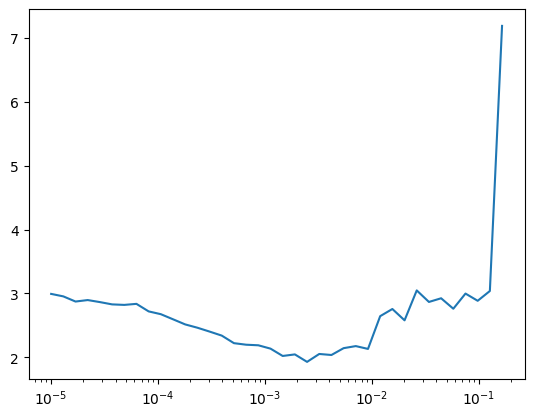

In [128]:
learn.lr_find()

{'accuracy': '0.216', 'loss': '2.430', 'train': 'train', 'epoch': 0}
{'accuracy': '0.283', 'loss': '2.107', 'train': 'valid', 'epoch': 0}


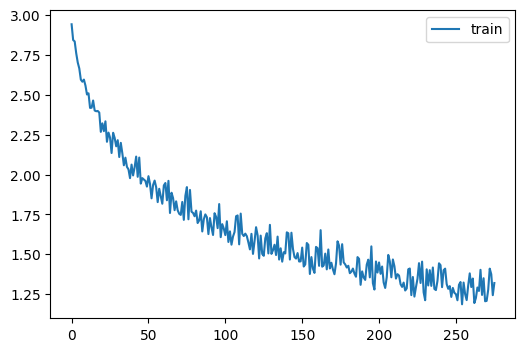

{'accuracy': '0.331', 'loss': '1.963', 'train': 'train', 'epoch': 1}
{'accuracy': '0.354', 'loss': '1.828', 'train': 'valid', 'epoch': 1}
{'accuracy': '0.377', 'loss': '1.748', 'train': 'train', 'epoch': 2}
{'accuracy': '0.396', 'loss': '1.687', 'train': 'valid', 'epoch': 2}
{'accuracy': '0.412', 'loss': '1.605', 'train': 'train', 'epoch': 3}
{'accuracy': '0.405', 'loss': '1.590', 'train': 'valid', 'epoch': 3}
{'accuracy': '0.439', 'loss': '1.504', 'train': 'train', 'epoch': 4}
{'accuracy': '0.430', 'loss': '1.535', 'train': 'valid', 'epoch': 4}
{'accuracy': '0.460', 'loss': '1.427', 'train': 'train', 'epoch': 5}
{'accuracy': '0.445', 'loss': '1.483', 'train': 'valid', 'epoch': 5}
{'accuracy': '0.485', 'loss': '1.359', 'train': 'train', 'epoch': 6}
{'accuracy': '0.447', 'loss': '1.450', 'train': 'valid', 'epoch': 6}
{'accuracy': '0.494', 'loss': '1.310', 'train': 'train', 'epoch': 7}
{'accuracy': '0.454', 'loss': '1.417', 'train': 'valid', 'epoch': 7}


KeyboardInterrupt: 

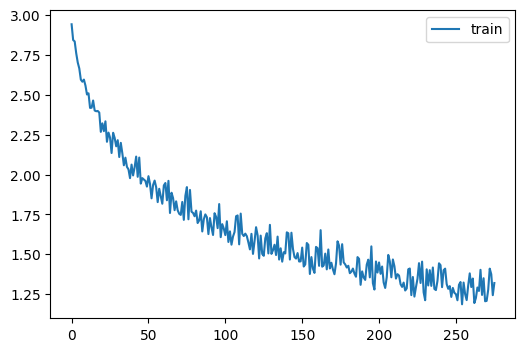

In [196]:
learn.fit(10,cbs=all_cbs,lr=1e-4)

- ooo wee look at me I've successfully attached the activations callback to monitor the inner activations of the model.
Now let's take a look at them.

In [198]:
acts_hook.hooks = [hook for hook in acts_hook.hooks if hasattr(hook, 'stats')]

In [199]:
len(acts_hook.hooks)

12

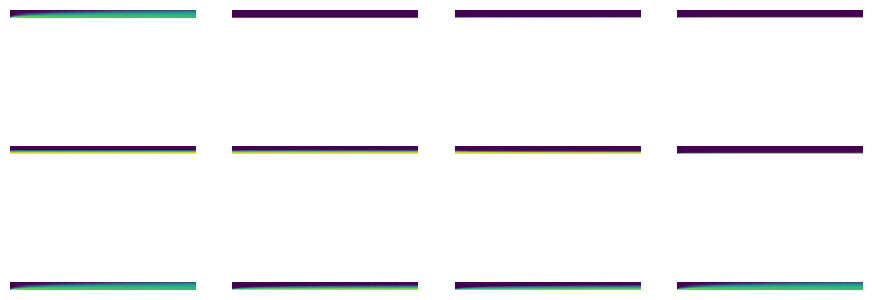

In [187]:
acts_hook.color_dim()

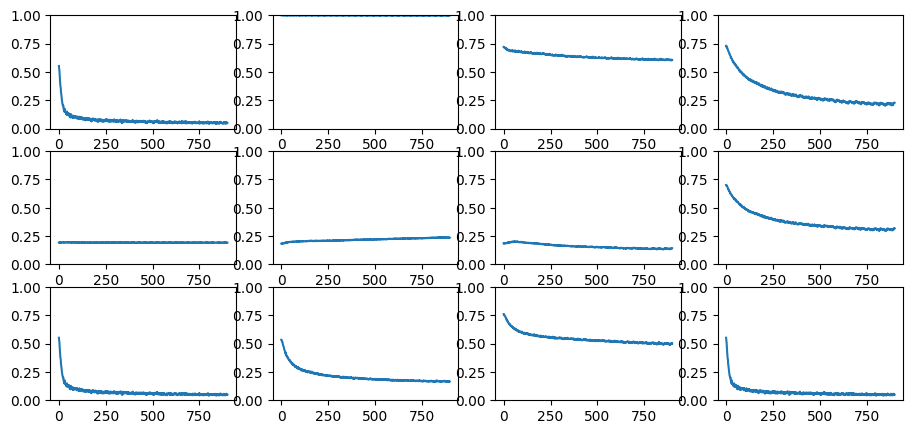

In [188]:
acts_hook.dead_chart()

In [139]:
#still not what I am looking for.

# Training

In [101]:
ds_train = CMIData(train, max_length=MAX_LENGTH)
train_loader = DataLoader(
    ds_train, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn, 
    drop_last=True
)
print(f"Training dataset contains: {len(ds_train)}")
ds_valid = CMIData(valid, max_length=MAX_LENGTH)
valid_loader = DataLoader(
    ds_valid,
    shuffle=False,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn,
    drop_last=True,
)
print(f"Valid dataset contains: {len(ds_valid)}")

Training dataset contains: 6520
Valid dataset contains: 1631


In [189]:
model = LSTMClassifier().to(DEVICE)
loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.1, patience=10, min_lr=LR_MIN
)

In [175]:
def evalute(model, data_loader, loss_fn):
    model.eval()
    loss = 0.0
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)
            loss += loss_fn(logits, y).item()
    model.train()
    return loss / len(data_loader)

In [190]:
def predict(model, data):
    model.eval()
    ds = CMIData(data, max_length=MAX_LENGTH)
    dl = DataLoader(
        ds, shuffle=False, batch_size=BATCH_SIZE, collate_fn=collate_fn, drop_last=False
    )
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            logits = model(x)
            y_pred.append(torch.argmax(logits, dim=-1).cpu().numpy())
            y_true.append(y.cpu().numpy())
    sol = pd.DataFrame(
        {"id": ds.keys, "gesture": cat.categories[np.concatenate(y_true)].values}
    )
    sub = pd.DataFrame(
        {"id": ds.keys, "gesture": cat.categories[np.concatenate(y_pred)].values}
    )
    return sol, sub

In [191]:
sol, sub = predict(model, valid)
cmi_score(sol, sub, "id")

0.14716468298678934

In [ ]:
class Monitor:
    def __init__(self):
        self.records = collections.defaultdict(list)

    def add(self, metric_name, epoch, value):
        self.records[metric_name].append({"epoch": epoch, "value": value})
        print(f"Epoch {epoch}/{EPOCHS} - {metric_name}: {value:.4g}")

    @property
    def dataframe(self):
        return pd.DataFrame(
            {
                k: pd.DataFrame(v).rename(columns={"value": k}).set_index("epoch")[k]
                for k, v in self.records.items()
            }
        )

In [ ]:
%%time

best_val_loss = float('inf')
best_val_score = float('-inf')

# training loop
monitor = Monitor()
for epoch in tqdm(range(1, EPOCHS + 1)):
    
    # training
    model.train()
    losses = []
    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x)
        loss = loss_fn(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    train_loss = np.mean(losses)
    monitor.add("train_loss", epoch, train_loss)
    
    # validation
    val_loss = evalute(model, valid_loader, loss_fn)
    monitor.add("val_loss", epoch, val_loss)
    sol, sub = predict(model, valid)
    val_score = cmi_score(sol, sub, "id")
    monitor.add("val_cmi", epoch, val_score)
    scheduler.step(val_loss)
    monitor.add("lr", epoch, optimizer.param_groups[0]['lr'])

    # checkpointing
    if val_loss < best_val_loss:
        print(f"Validation loss improved from {best_val_loss:.4f} to {val_loss:.4}")
        path_model = OUT_DIR / "model_best.pt"
        torch.save(model.state_dict(), path_model)
        best_val_loss = val_loss

    # checkpointing
    if val_score > best_val_score:
        print(f"Validation score improved from {best_val_score:.4f} to {val_score:.4}")
        path_model_score = OUT_DIR / "model_best_score.pt"
        torch.save(model.state_dict(), path_model_score)
        best_val_score = val_score

  0%|          | 0/70 [00:00<?, ?it/s]

Epoch 1/70 - train_loss: 2.608
Epoch 1/70 - val_loss: 2.552
Epoch 1/70 - val_cmi: 0.4236
Epoch 1/70 - lr: 0.001
Validation loss improved from inf to 2.552
Validation score improved from -inf to 0.4236
Epoch 2/70 - train_loss: 2.537
Epoch 2/70 - val_loss: 2.529
Epoch 2/70 - val_cmi: 0.3676
Epoch 2/70 - lr: 0.001
Validation loss improved from 2.5515 to 2.529
Epoch 3/70 - train_loss: 2.494
Epoch 3/70 - val_loss: 2.461
Epoch 3/70 - val_cmi: 0.4849
Epoch 3/70 - lr: 0.001
Validation loss improved from 2.5294 to 2.461
Validation score improved from 0.4236 to 0.4849
Epoch 4/70 - train_loss: 2.412
Epoch 4/70 - val_loss: 2.33
Epoch 4/70 - val_cmi: 0.4792
Epoch 4/70 - lr: 0.001
Validation loss improved from 2.4614 to 2.33
Epoch 5/70 - train_loss: 2.313
Epoch 5/70 - val_loss: 2.229
Epoch 5/70 - val_cmi: 0.5357
Epoch 5/70 - lr: 0.001
Validation loss improved from 2.3298 to 2.229
Validation score improved from 0.4849 to 0.5357
Epoch 6/70 - train_loss: 2.284
Epoch 6/70 - val_loss: 2.269
Epoch 6/70 - 

KeyboardInterrupt: 

In [ ]:
hist = monitor.dataframe
hist.to_csv(OUT_DIR / "history.csv")
hist

,train_loss,val_loss,val_cmi,lr
epoch,,,,
1,2.608254,2.551543,0.423608,0.001
2,2.536789,2.529378,0.367605,0.001
3,2.493584,2.461382,0.484907,0.001
4,2.411673,2.329774,0.479198,0.001
5,2.313154,2.228566,0.535674,0.001
6,2.284380,2.268503,0.511172,0.001
7,2.225086,2.167770,0.557211,0.001
8,2.183743,2.162573,0.552497,0.001
9,2.140536,2.092131,0.570231,0.001


In [ ]:
hist.loc[hist["val_loss"].idxmin()]

train_loss    1.415868
val_loss      1.797070
val_cmi       0.671300
lr            0.001000
Name: 27, dtype: float64

In [ ]:
hist.loc[hist["val_cmi"].idxmax()]

train_loss    1.504180
val_loss      1.838646
val_cmi       0.677327
lr            0.001000
Name: 25, dtype: float64

NameError: name 'hist' is not defined

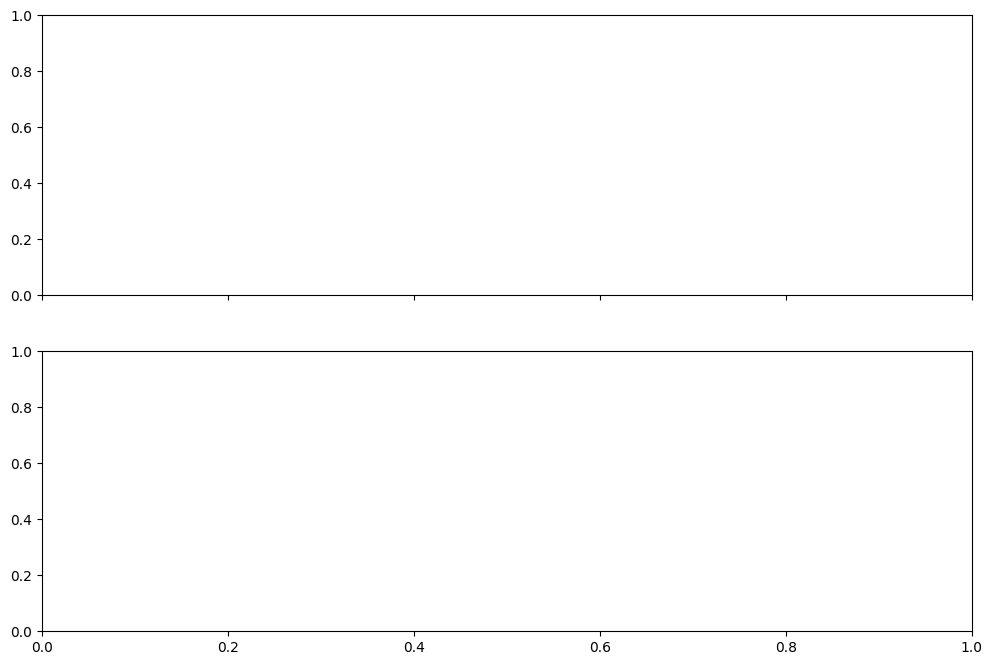

In [104]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 8), sharex="col")
plt_kwargs = dict(grid=True, marker='x')
hist[["train_loss", "val_loss"]].plot(ax=axs[0], **plt_kwargs)
hist[["val_cmi"]].plot(ax=axs[1], **plt_kwargs)
plt.show()

# Eval

In [109]:
torch.save(model.state_dict(), OUT_DIR / "lstm_weights_first.pth")

In [ ]:
model.load_state_dict(torch.load(path_model, weights_only=True))

<All keys matched successfully>

In [83]:
sol, sub = predict(model, valid)
cmi_score(sol, sub, "id")

0.3944116347311109

In [ ]:
model.load_state_dict(torch.load(path_model_score, weights_only=True))

<All keys matched successfully>

In [84]:
sol, sub = predict(model, valid)
cmi_score(sol, sub, "id")

0.3944116347311109